<font color="green"><font size="6">**AIDS Virus Infection Prediction**</font></font>

Dataset contains healthcare statistics and categorical information about patients who have been diagnosed with AIDS.

<font size="5">Attribute Information:</font>
- <font size="4">**time**</font> : time to failure or censoring. The time in hours/days elapsed until an event of interest (development of advanced symptoms or the achievement of a specific health state) occurs.Or it is the censoring time, i.e. the patient is still under treatment or has not yet reached the event of interest.
- <font size="4">**trt**</font> : treatment indicator (0 = ZDV; 1 = ZDV + ddI, 2 = ZDV + Zal, 3 = ddI). Where ZDV = zidovudine, ddI = didanosine, Zal = zalcitabine.
- <font size="4">**age**</font> : age (yrs) at baseline
- <font size="4">**wtkg**</font> : weight (kg) at baseline
- <font size="4">**hemo**</font> : hemophilia (0=no, 1=yes)
- <font size="4">**homo**</font> : homosexual activity (0=no, 1=yes)
- <font size="4">**drugs**</font> :  history of IV drug use (0=no, 1=yes)
- <font size="4">**karnof**</font> : Karnofsky score (on a scale of 0-100). It is a system used to evaluate the functional status and autonomy of a patient with a disease.The Karnofsky score ranges from 100 to 0, where:
100 represents a perfect state of health and normal activity without signs of illness; 0 represents a state of coma or death.
- <font size="4">**oprior**</font> : Non-ZDV antiretroviral therapy pre-175 (0=no, 1=yes). So, it evaluates whether the patient has undergone non-zidovudine-based antiretroviral therapy prior to initiating treatment (175 weeks earlier).
- <font size="4">**z30**</font> : ZDV was administered in the 30 days prior to the 175-week mark of observation. (0=no, 1=yes)
- <font size="4">**preanti**</font> : days pre-175 antiretroviral therapy. Number of days or the duration that a patient has been on anti-retroviral therapy before reaching the 175-week mark since the start of observation or treatment.
- <font size="4">**race**</font> : race (0=White, 1=non-white)
- <font size="4">**gender**</font> : gender (0=F, 1=M)
- <font size="4">**str2**</font> : antiretroviral history (0=naive, 1=experienced). "Naive" indicates that the patient have had no prior experience with antiretroviral therapy (they are newly diagnosed or have not yet started treatment for HIV); while "experienced" indicates that the patient has had prior experience with antiretroviral drugs, meaning they have received antiretroviral treatments in the past (with continuous treatment over time or interrupted and restarted).
- <font size="4">**strat**</font> :  antiretroviral history stratification (1 = 'Antiretroviral Naive', 2 = '> 1 but <= 52 weeks of prior antiretroviral therapy', 3 = '> 52 weeks')
- <font size="4">**symptom**</font> : symptomatic indicator (0=asymp, 1=symp)
- <font size="4">**treat**</font> : treatment indicator (0=ZDV only, 1=others)
- <font size="4">**offtrt**</font> : indicator of off-trt before 96+/-5 weeks (0=no,1=yes). Indicator related to treatment cessation (off-trt) within a specific period of time.
- <font size="4">**cd40**</font> : CD4 at baseline. CD4 is a surface protein found primarily on cells of the human immune system called helper T lymphocytes. HIV selectively attacks and destroys CD4+ cells, progressively weakening the immune system and making the body more vulnerable to opportunistic infections and other complications.Therefore, the count of CD4+ cells is used as an indicator to assess the severity of HIV infection and to monitor the progression of the disease over time.
- <font size="4">**cd420**</font> : CD4 at 20+/-5 weeks
- <font size="4">**cd80**</font> : CD8 at baseline. The CD8 is a surface protein found primarily on cells of the human immune system called cytotoxic T lymphocytes. These cells play a crucial role in defending the body against viral infections and tumor cells.
- <font size="4">**cd820**</font> :  CD8 at 20+/-5 weeks
- <font size="4">**infected**</font> : target variable. The patient is infected with AIDS (0=No, 1=Yes)


In [20]:
import pandas as pd
import numpy as np

# Read the dataset using pandas
AIDS_data = pd.read_csv('AIDS_Classification_5000.csv')

AIDS_data.head()

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,infected
0,988,2,42,71.76131,0,0,0,100,0,1,...,1,3,0,0,0,290,408,1870,1671,0
1,413,3,30,72.67629,0,1,0,100,0,1,...,0,1,0,0,0,506,446,1372,523,0
2,1119,0,37,73.75514,0,1,0,90,0,1,...,1,3,0,0,0,499,542,609,1474,0
3,680,3,34,70.03769,0,0,0,100,0,0,...,0,1,0,1,0,313,478,780,987,0
4,1043,3,35,63.02845,0,0,0,100,0,1,...,0,1,0,1,0,337,761,698,1735,0


<font color="orange"><font size="4">EDA (Exploratory Data Analysis)</font></font>

- <font color="purple"><font size="4">Preliminary analysis:</font></font>

In [2]:
AIDS_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   time      5000 non-null   int64  
 1   trt       5000 non-null   int64  
 2   age       5000 non-null   int64  
 3   wtkg      5000 non-null   float64
 4   hemo      5000 non-null   int64  
 5   homo      5000 non-null   int64  
 6   drugs     5000 non-null   int64  
 7   karnof    5000 non-null   int64  
 8   oprior    5000 non-null   int64  
 9   z30       5000 non-null   int64  
 10  preanti   5000 non-null   int64  
 11  race      5000 non-null   int64  
 12  gender    5000 non-null   int64  
 13  str2      5000 non-null   int64  
 14  strat     5000 non-null   int64  
 15  symptom   5000 non-null   int64  
 16  treat     5000 non-null   int64  
 17  offtrt    5000 non-null   int64  
 18  cd40      5000 non-null   int64  
 19  cd420     5000 non-null   int64  
 20  cd80      5000 non-null   int6

In [21]:
# Printing some useful information for analysis
print("Number of HIV infected (1) and non-infected (0) patients:")
print(AIDS_data.value_counts("infected"))
print("\n")
print(AIDS_data.isnull().sum())
print("\n")

# Checks if there are null values ​​throughout the DataFrame
if AIDS_data.isnull().sum().sum() == 0:
    print("There are not missing values.")
else: 
    print("There are missing values, they need to be handled.")


Number of HIV infected (1) and non-infected (0) patients:
infected
0    3421
1    1579
Name: count, dtype: int64


time        0
trt         0
age         0
wtkg        0
hemo        0
homo        0
drugs       0
karnof      0
oprior      0
z30         0
preanti     0
race        0
gender      0
str2        0
strat       0
symptom     0
treat       0
offtrt      0
cd40        0
cd420       0
cd80        0
cd820       0
infected    0
dtype: int64


There are not missing values.


In [4]:
# Basic statistical information
print(AIDS_data.describe())

              time          trt          age         wtkg         hemo  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean    881.382400     1.375200    34.239800    75.941660     0.033000   
std     303.774994     1.235609     6.985732    12.448553     0.178654   
min     124.000000     0.000000    12.000000    44.424990     0.000000   
25%     552.000000     0.000000    29.000000    68.039777     0.000000   
50%    1044.500000     1.000000    34.000000    74.009940     0.000000   
75%    1136.000000     3.000000    39.000000    81.224572     0.000000   
max    1231.000000     3.000000    62.000000   142.881280     1.000000   

              homo        drugs       karnof       oprior         z30  ...  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.00000  ...   
mean      0.648000     0.137000    96.893400     0.040600     0.64020  ...   
std       0.477642     0.343882     5.013608     0.197381     0.47999  ...   
min       0.000000   

- <font color="purple"><font size="3">Types of data</font></font>
- <font color="purple"><font size="3">Plots</font></font>
- <font color="purple"><font size="3">Dealing with outliers</font></font>
- <font color="purple"><font size="3">Correlation and importance of variables</font></font>
- <font color="purple"><font size="3">Scaling</font></font>

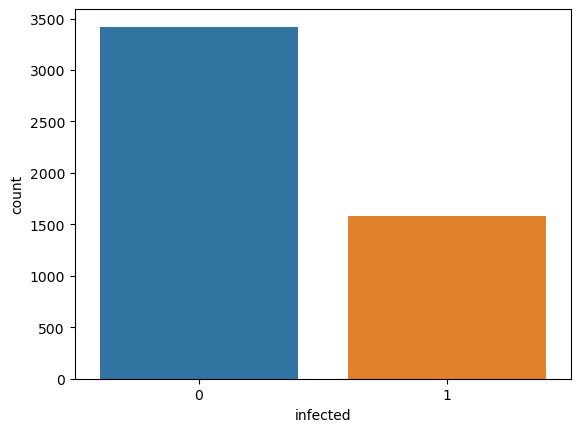

Percentage of elements for each class:
infected
0    68.42
1    31.58
Name: count, dtype: float64


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Counting elements in each class
sns.countplot(x='infected', data=AIDS_data)
plt.show()

# In percentage:
class_counts = AIDS_data['infected'].value_counts() # number of elements per class
total_count = len(AIDS_data)
class_percentages = (class_counts / total_count) * 100
print("Percentage of elements for each class:")
print(class_percentages)


In [23]:
# Some percentage

# - Percentage of people who recovered after being treated with ZDV alone:
# Filter rows where patients are not infected
non_infected_df = AIDS_data[AIDS_data['infected'] == 0]

# Number of uninfected patients who were treated with ZDV only
trt0_count = non_infected_df[non_infected_df['trt'] == 0].shape[0]

# Total number of non infected patients
total_non_infected_count = non_infected_df.shape[0]

# Percentage of uninfected patients with 'trt'= 0 compared to total uninfected patients
percentage = (trt0_count / total_non_infected_count) * 100

print(f"Number of uninfected patients who were treated with ZDV only: {trt0_count}")
print(f"Percentage of uninfected patients with 'trt'= 0 compared to total uninfected patients: {percentage:.2f}%")

# - Percentage of people who recovered after being treated with ZDV + ddl:
trt1_count = non_infected_df[non_infected_df['trt'] == 1].shape[0]
percentage = (trt1_count / total_non_infected_count) * 100

print('\n')
print(f"Number of uninfected patients who were treated with ZDV+ddl: {trt1_count}")
print(f"Percentage of uninfected patients with 'trt'= 1 compared to total uninfected patients: {percentage:.2f}%")

# - Percentage of people who recovered after being treated with ZDV + Zar:
trt2_count = non_infected_df[non_infected_df['trt'] == 2].shape[0]
percentage = (trt2_count / total_non_infected_count) * 100

print('\n')
print(f"Number of uninfected patients who were treated with ZDV+Zar: {trt2_count}")
print(f"Percentage of uninfected patients with 'trt'= 2 compared to total uninfected patients: {percentage:.2f}%")


# - Percentage of people who recovered after being treated with ddl only:
trt3_count = non_infected_df[non_infected_df['trt'] == 3].shape[0]
percentage = (trt3_count / total_non_infected_count) * 100

print('\n')
print(f"Number of uninfected patients who were treated with ddl only: {trt3_count}")
print(f"Percentage of uninfected patients with 'trt'= 1 compared to total uninfected patients: {percentage:.2f}%")

# - Percentage of people cured among all people treated with ZDV only:

trt0_df = AIDS_data[AIDS_data['trt'] == 0]
recovered_count = trt0_df[trt0_df['infected'] == 0].shape[0]
total_trt0_count = trt0_df.shape[0]

percentage_recovered = (recovered_count / total_trt0_count) * 100

print('-----------------------------------------------------------------------------------------------')
print(f"Number of people cured treated with ZDV alone: {recovered_count}")
print(f"Percentage of people cured among all those treated with ZDV only: {percentage_recovered:.2f}%")


Number of uninfected patients who were treated with ZDV only: 1210
Percentage of uninfected patients with 'trt'= 0 compared to total uninfected patients: 35.37%


Number of uninfected patients who were treated with ZDV+ddl: 518
Percentage of uninfected patients with 'trt'= 1 compared to total uninfected patients: 15.14%


Number of uninfected patients who were treated with ZDV+Zar: 756
Percentage of uninfected patients with 'trt'= 2 compared to total uninfected patients: 22.10%


Number of uninfected patients who were treated with ddl only: 937
Percentage of uninfected patients with 'trt'= 1 compared to total uninfected patients: 27.39%
-----------------------------------------------------------------------------------------------
Number of people cured treated with ZDV alone: 1210
Percentage of people cured among all those treated with ZDV only: 64.19%


In [24]:
# Division of numerical and categorical variables for subsequent analysis

# Initializing empty lists
cat_features = []
num_columns =[]

for col in AIDS_data.columns:
    # Number of unique values in a column of the dataset
    num_unique_values = AIDS_data[col].nunique()
    
    # Add column to one of the two lists (the data is all numbers)
    if num_unique_values <= 4:
        cat_features.append(col)
    else:
        num_columns.append(col)


print("Categorical features:", cat_features)
print("Numerical features:", num_columns)

# Deleting the target column from the list
cat_columns = cat_features[:-1]


Categorical features: ['trt', 'hemo', 'homo', 'drugs', 'oprior', 'z30', 'race', 'gender', 'str2', 'strat', 'symptom', 'treat', 'offtrt', 'infected']
Numerical features: ['time', 'age', 'wtkg', 'karnof', 'preanti', 'cd40', 'cd420', 'cd80', 'cd820']


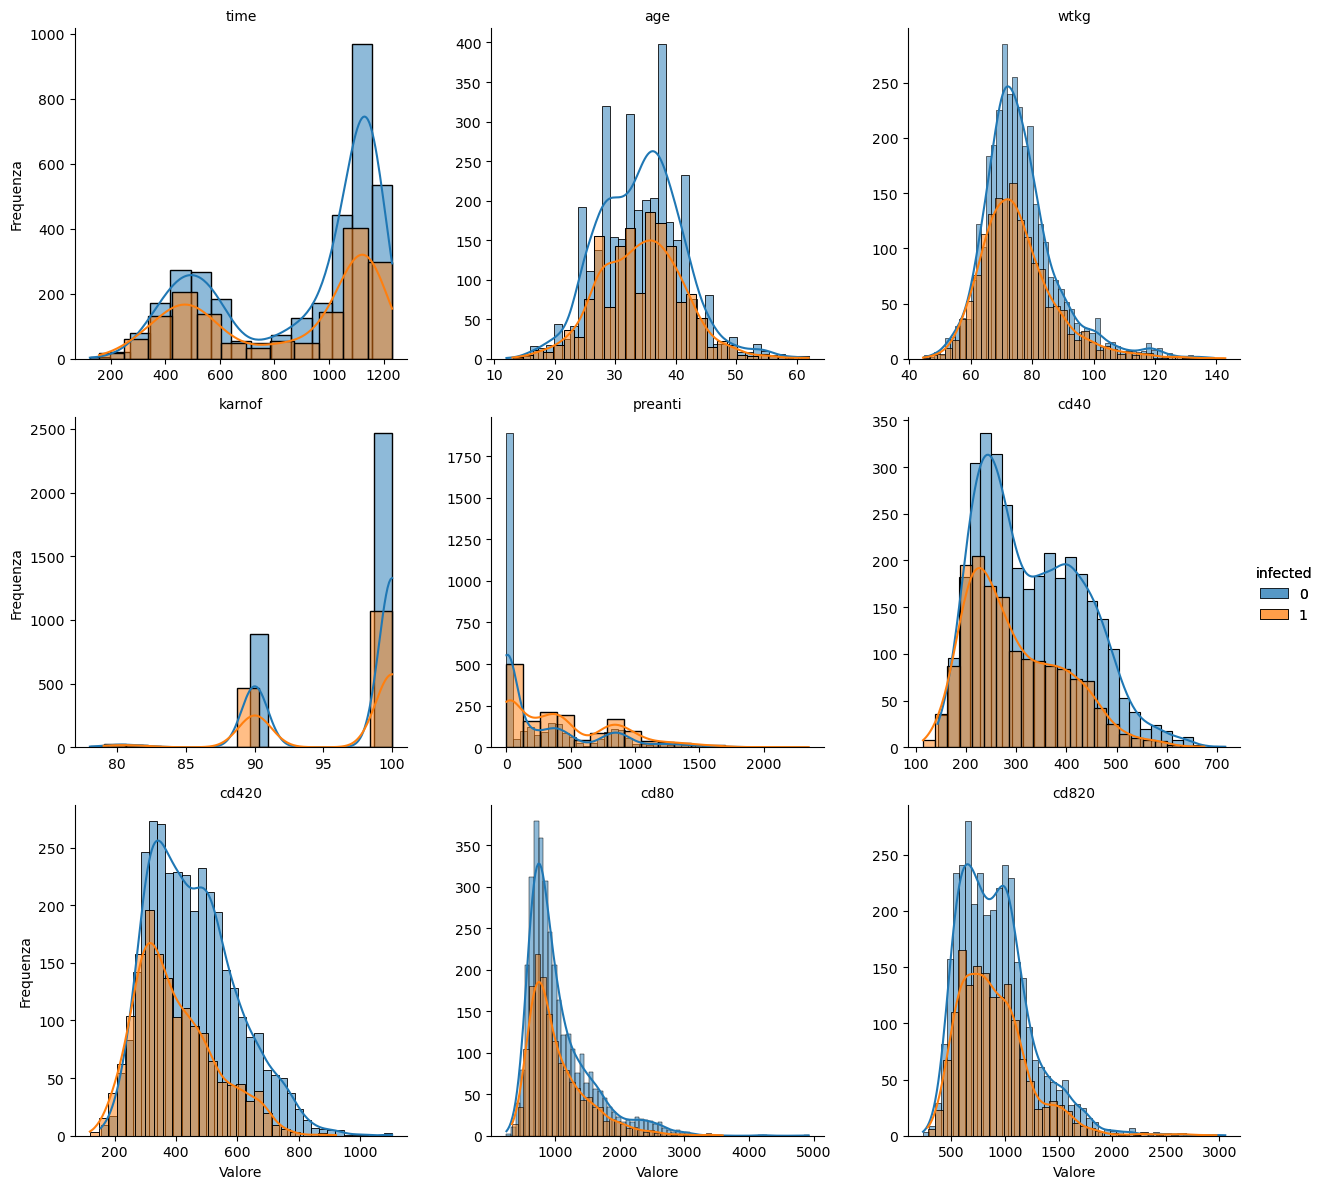

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Reshape the dataset for plotting
plot_data = AIDS_data.melt(
    id_vars='infected',
    value_vars=num_columns,
    var_name='variable',
    value_name='value'
)

# Convert possible infinite values to NaN and remove them only for plotting
plot_data['value'] = plot_data['value'].replace([np.inf, -np.inf], np.nan)
plot_data = plot_data.dropna(subset=['value'])

# Creation of the FacetGrid with histplot for numeric variables
g = sns.FacetGrid(
    plot_data,
    col='variable',
    hue='infected',
    col_wrap=3,
    height=4,
    sharex=False,
    sharey=False
)

# Distribution plots
# The FutureWarning comes from seaborn/pandas internals in some versions.
# Data have already been cleaned for infinite/missing values above.
with warnings.catch_warnings():
    warnings.simplefilter('ignore', FutureWarning)
    g.map_dataframe(sns.histplot, x='value', kde=True)

g.set_axis_labels('Value', 'Frequency')
g.set_titles(col_template='{col_name}')
g.add_legend()

plt.show()

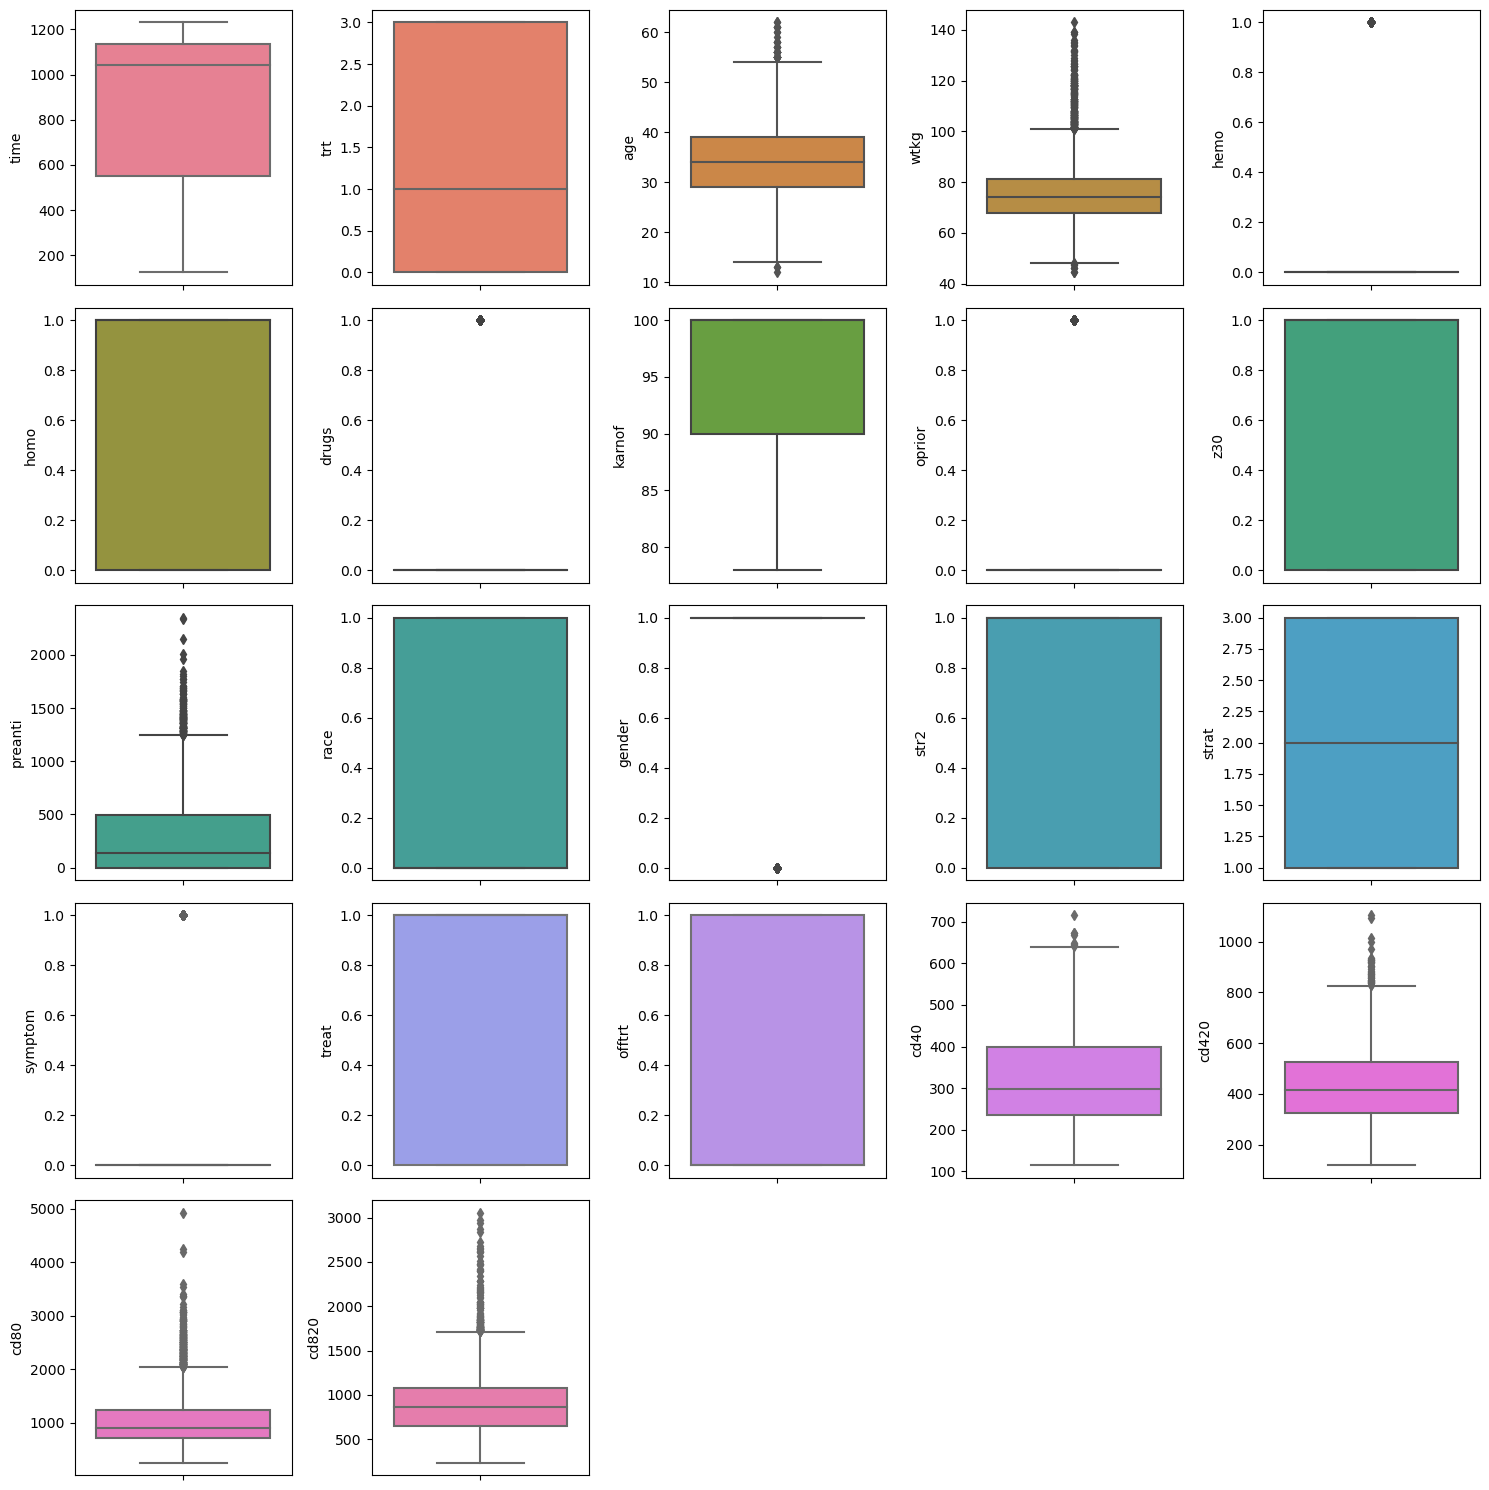

In [26]:
# OUTLIERS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Boxplots

# Dataframe without 'infected' column
AIDS_notarg = pd.DataFrame(AIDS_data.drop('infected', axis=1))

# Subplots
fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(15, 15))
index = 0
axs = axs.flatten()

# Create a color palette (with n_colors different colors)
colors = sns.color_palette("husl", n_colors=len(AIDS_notarg.columns))

for k,v in AIDS_notarg.items():
    sns.boxplot(y=k, data=AIDS_notarg, ax=axs[index], color = colors[index % len(colors)])
    index += 1

# Hide empty axes
for j in range(index, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()


In [27]:
# Class for the Outliers
from sklearn.base import BaseEstimator, TransformerMixin

class Outliers_remove(BaseEstimator, TransformerMixin): # Outliers_remove is a subclass of the two scikit-learn classes
    # Initialize class members
    def __init__(self, column_conditions):
        self.column_conditions = column_conditions # dictionary
        self.bounds_ = {}
    
    def fit(self, X, y=None):
        """
            This method calculates and stores in a dictionary the value limits for each column of a DataFrame X,
            using the Interquartile Range (IQR) to establish these boundaries.

            :arg: X = Dataframe 
                y = target variable (None)
            :return: self = the object instance
        """
        
        for col, conditions in self.column_conditions.items():
            if col in X.columns: # if the current column is present in X
                # Calculation of the first, third quartiles and the IQR
                Q1 = X[col].quantile(0.25)
                Q3 = X[col].quantile(0.75)
                IQR = Q3 - Q1
                
                # Get IQR multipliers from conditions or use 1.5 as default
                lower_iqr_multiplier = conditions.get('lower_iqr_multiplier', 1.5)
                upper_iqr_multiplier = conditions.get('upper_iqr_multiplier', 1.5)

                # Compute IQR based bounds               
                if lower_iqr_multiplier is None:
                    lower_bound = None
                else:
                   lower_bound = Q1 - lower_iqr_multiplier * IQR

                if upper_iqr_multiplier is None:
                    upper_bound = None
                else:
                    upper_bound = Q3 + upper_iqr_multiplier * IQR

                # Get limits from conditions or use calculated limits based on the IQR 
                specific_lower_bound = conditions.get('lower_bound', lower_bound)
                specific_upper_bound = conditions.get('upper_bound', upper_bound)
                
                # Saving limits in the bounds_ (class attribute)
                self.bounds_[col] = {
                    'lower_bound': specific_lower_bound,
                    'upper_bound': specific_upper_bound
                }
        return self
        
    def transform(self, X, y=None):
        """
            This method is used to manage outliers and ensure that they remain within a specific range.

            :arg: X = Dataframe 
                y = target variable (None)
            :return: X_transformed = modified Dataframe 
        """

        # create a copy of X
        X_transformed = X.copy()

        if isinstance(X_transformed, pd.DataFrame):  # if X_transformed is a dataframe
            # Iterates over all columns for which conditions have been specified 
            for col in self.column_conditions.keys():
                if col in self.bounds_:
                    # Extracts the lower and upper bounds stored for the current column
                    lower_bound = self.bounds_[col]['lower_bound']
                    upper_bound = self.bounds_[col]['upper_bound']

                    # Modification ​​of outliers
                    if lower_bound is not None:
                        X_transformed[col] = np.where(X_transformed[col] < lower_bound,
                                                      lower_bound,
                                                      X_transformed[col])
                    if upper_bound is not None:
                        X_transformed[col] = np.where(X_transformed[col] > upper_bound, 
                                                       upper_bound, 
                                                       X_transformed[col])
        return X_transformed 
    
     

In [28]:
# Division of the dataset between features and target variable
X = AIDS_data.drop(columns=['infected'])
y = AIDS_data['infected']


# Define conditions for some columns
column_conditions = {
    'age': {'lower_bound': 12,'upper_iqr_multiplier':None}, # the study was done for patients aged 12 years and older
    'preanti': {'upper_iqr_multiplier': 2} # elimination of outliers above the value 1500
}   

# Create an instance of the Outliers_remove class
outlier_remover =  Outliers_remove(column_conditions = column_conditions)
outlier_remover.fit(X) 

X_transformed = outlier_remover.transform(X)  
# Keep the target as a 1D array to avoid sklearn DataConversionWarning
y_transformed = y.to_numpy().ravel()


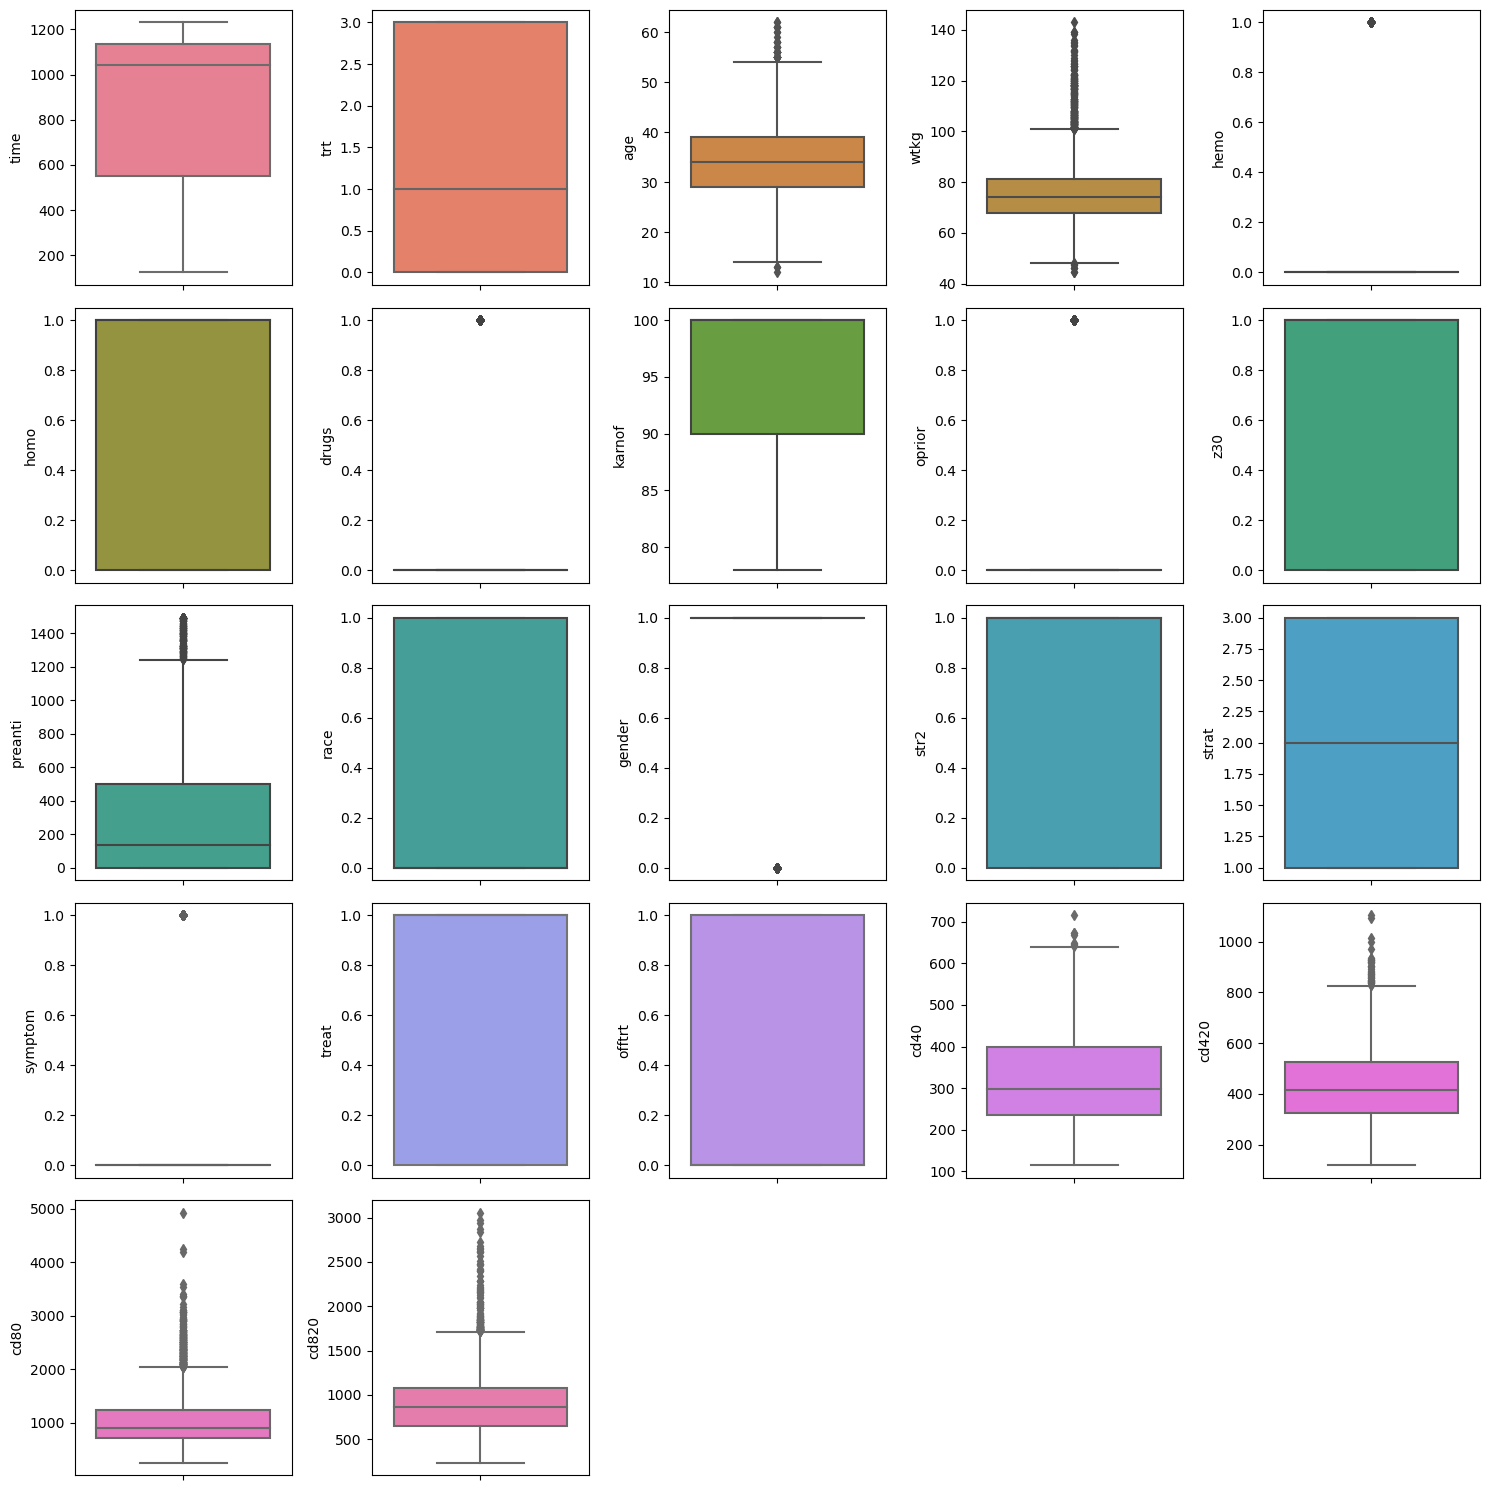

In [29]:
# Outliers after evaluation

# subplots
fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(15, 15))
index = 0
axs = axs.flatten()

colors = sns.color_palette("husl", n_colors=len(X_transformed.columns))

for k,v in X_transformed.items():
    sns.boxplot(y=k, data=X_transformed, ax=axs[index], color = colors[index % len(colors)])
    index += 1

# Hide empty axes
for j in range(index, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()


In [30]:
from sklearn.preprocessing import OneHotEncoder

# Observation: Assigning integers to non-ordinal categories could cause the model to interpret an order that 
# does not exist, leading to distorted results.

# One-Hot Encoding for the nominal categorical variable trt
encoder = OneHotEncoder()
transformed = encoder.fit_transform(X_transformed['trt'].to_numpy().reshape(-1, 1)).toarray()
ohe_df = pd.DataFrame(transformed, columns=encoder.get_feature_names_out(['trt']))

# Concatenate with original data and drop categorial column
X_transformed = pd.concat([X_transformed, ohe_df], axis=1).drop(['trt'], axis=1)

# Total Dataset
data_transformed = pd.concat([X_transformed, AIDS_data['infected']], axis=1)

# Redefine the lists of categorical and numeric variables
cat_columns.extend(ohe_df.columns.tolist())
cat_columns.remove('trt')
cat_features = list(cat_columns)
cat_features.append('infected')

print(cat_columns)
print(cat_features)

['hemo', 'homo', 'drugs', 'oprior', 'z30', 'race', 'gender', 'str2', 'strat', 'symptom', 'treat', 'offtrt', 'trt_0', 'trt_1', 'trt_2', 'trt_3']
['hemo', 'homo', 'drugs', 'oprior', 'z30', 'race', 'gender', 'str2', 'strat', 'symptom', 'treat', 'offtrt', 'trt_0', 'trt_1', 'trt_2', 'trt_3', 'infected']


In [13]:
X_transformed.head()

,time,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,preanti,...,treat,offtrt,cd40,cd420,cd80,cd820,trt_0,trt_1,trt_2,trt_3
0,988,42,71.76131,0,0,0,100,0,1,911.0,...,0,0,290,408,1870,1671,0.0,0.0,1.0,0.0
1,413,30,72.67629,0,1,0,100,0,1,414.0,...,0,0,506,446,1372,523,0.0,0.0,0.0,1.0
2,1119,37,73.75514,0,1,0,90,0,1,810.0,...,0,0,499,542,609,1474,1.0,0.0,0.0,0.0
3,680,34,70.03769,0,0,0,100,0,0,0.0,...,1,0,313,478,780,987,0.0,0.0,0.0,1.0
4,1043,35,63.02845,0,0,0,100,0,1,3.0,...,1,0,337,761,698,1735,0.0,0.0,0.0,1.0


Number of unique values in the karnof feature:  9




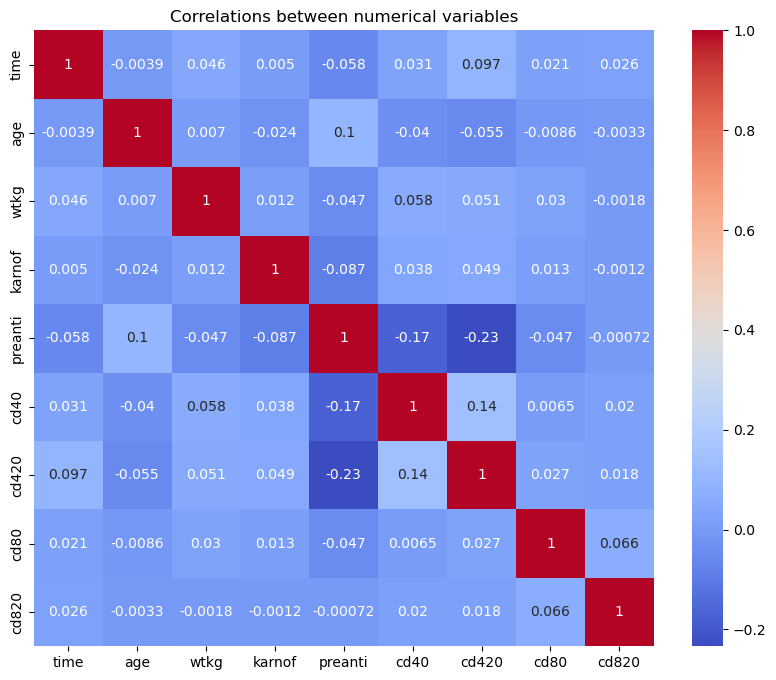

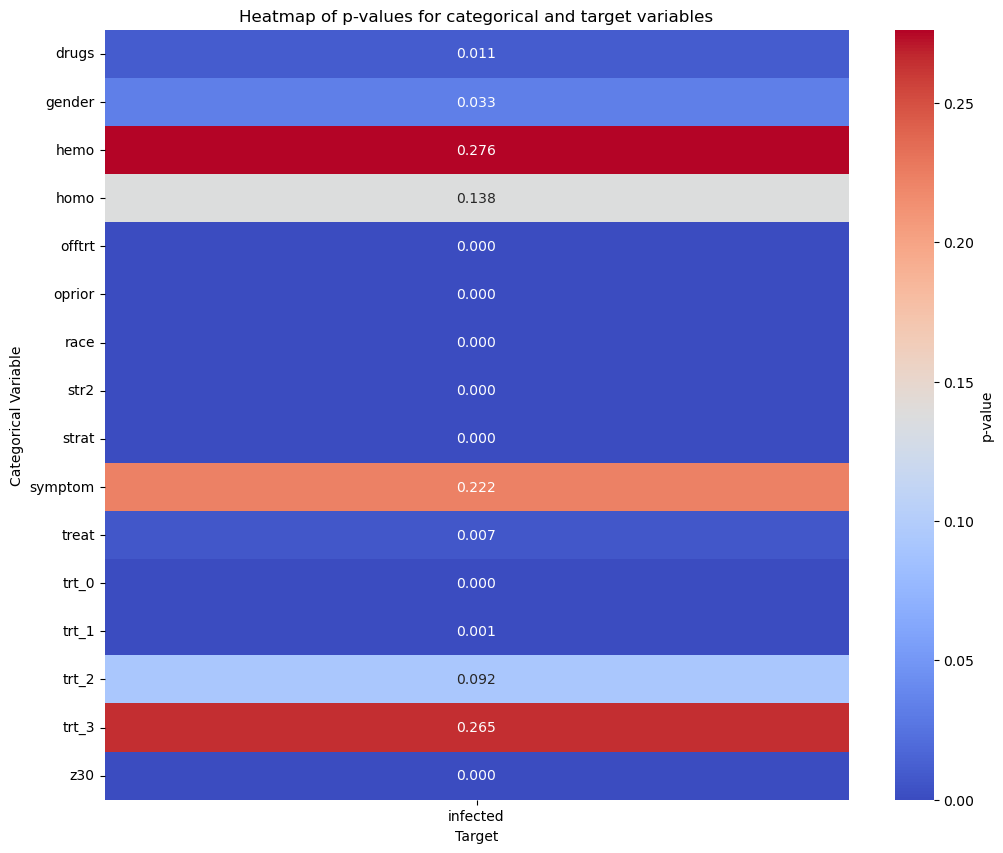

In [31]:
# CORRELATIONS

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency


# Numerical variables 
# Pearson correlation

# Note! Some of them discrete but in a wide range, therefore treated as continuous with Pearson correlation
# observation:
unique_karnof = X_transformed['karnof'].nunique()
print('Number of unique values in the karnof feature: ',unique_karnof)
print('\n')


correlation_matrix = X_transformed[num_columns].corr() # correlation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlations between numerical variables')
plt.show()

# Want to eliminate one of the highly correlated variables to reduce multicollinearity and simplify the model.


# Categorical variables 
# Contingency table and Chi-square test

def chi2_test(df, cat_cols, target_col):
    """
        Function to perform the Chi-square test between categorical and target variables.

        :arg: cat_cols = categorical features
              target_col 
        :return: pd.DataFrame(results) =  Dataframe of a list
    """
    
    results = []
    
    for cat_col in cat_cols:        
        # Contingency table between the categorical variable and the target variable
        contingency_table = pd.crosstab(df[cat_col], df[target_col])
        # Chi-square test:
        chi2, p, dof, expected = chi2_contingency(contingency_table)

        # add results to a list
        results.append({
            'Categorical Variable': cat_col,
            'Target': target_col,
            'Chi2': chi2,
            'p-value': p,
            'Degrees of Freedom': dof
        })
    
    return pd.DataFrame(results)



results_df = chi2_test(data_transformed,cat_columns,cat_features[-1])

# Transforming results_df into a matrix for visualization
heatmap_data = results_df.pivot(index='Categorical Variable', columns='Target', values='p-value')

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='coolwarm', cbar_kws={'label': 'p-value'})
plt.title('Heatmap of p-values for categorical and target variables')
plt.show()

# Note! A low p value (typically < 0.05) indicates a significant association between the variables.

# If the p value between a categorical variable and the target variable is greater than 0.05, 
# it means that there is no statistically significant relationship between that variable and the target. 
# The variable may not contribute much to predicting the target.


In [32]:
from sklearn.ensemble import RandomForestClassifier

# Use of the random forest to evaluate which variables contribute most to the model
model = RandomForestClassifier(random_state=42)
model.fit(X_transformed, np.ravel(y_transformed))

# Importance of the variables
importances = model.feature_importances_
importance_df = pd.DataFrame({'Feature': X_transformed.columns, 'Importance': importances})
print(importance_df.sort_values(by='Importance', ascending=False))

    Feature  Importance
18    cd420    0.105585
9   preanti    0.104879
0      time    0.099373
17     cd40    0.099319
2      wtkg    0.095442
20    cd820    0.092008
19     cd80    0.091346
1       age    0.074490
13    strat    0.034842
12     str2    0.026078
8       z30    0.022045
6    karnof    0.019859
15    treat    0.013844
16   offtrt    0.013633
4      homo    0.013622
21    trt_0    0.012600
10     race    0.012590
11   gender    0.010638
24    trt_3    0.010343
5     drugs    0.010299
23    trt_2    0.010095
22    trt_1    0.008714
14  symptom    0.007439
7    oprior    0.006577
3      hemo    0.004340


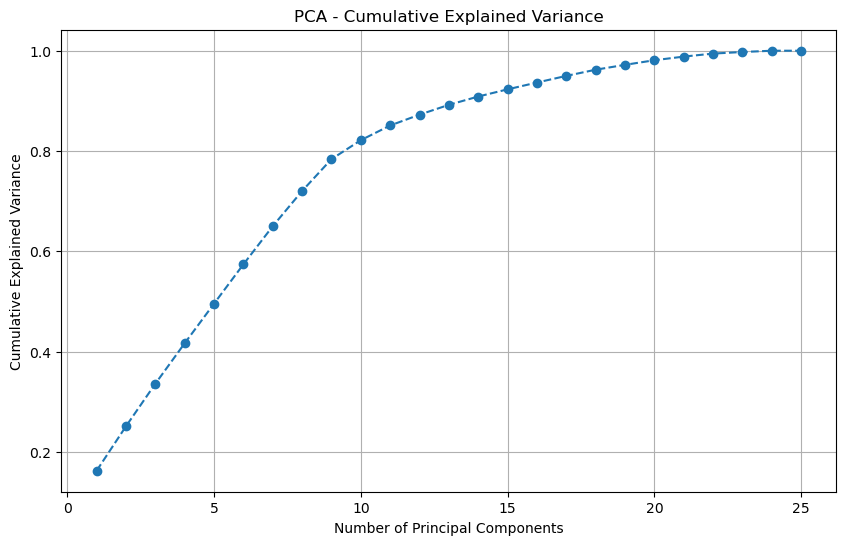

In [33]:
# PCA for analysis of variance:
# If a few components explain most of the variance, then the original dataset has redundant characteristics.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Data normalization
Xnum_normalized = StandardScaler().fit_transform(X_transformed[num_columns])
X_normalized = X_transformed.copy()
X_normalized[num_columns]=Xnum_normalized

# PCA
pca = PCA()
pca.fit(X_normalized)

# Explained variance graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.grid()
plt.show()

# Cumulative Explained Variance: Represents the cumulative percentage of the total variance of the dataset 
# explained by the first n principal components.


In [34]:
# Use of all the techniques seen previously for dropping unnecessary and redundant columns

from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Dropping # X = data_transformed (contiene X e y); 
def drop_features(X, num, cat, corr_threshold, pvalue_threshold):
    """
        Function that identifies columns to remove based on correlation, chi-square tests, Random Forest and PCA.
        
        :arg: X = input Dataset
              num = list of numeric features
              cat = list of categorical features
              corr_threshold = threshold value above which numeric columns are considered highly correlated
              p_value_threshold = p-value threshold for the chi-square test on categorical variables
            
        
        :return: X_dropped = dropped Dataset
                 final_columns_to_drop = list of columns to remove
    """
    
    to_drop = set()
    
    # Part 1: Correlation between numerical variables
    corr_matrix = X[num].corr().abs()
    
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) # upper triangular matrix
                                                                                     # k=1 : keep the elements above the main diagonal
    
    for column in upper.columns:
        # List of column names that are highly correlated with the current column.
        correlated_columns = upper.index[upper[column] > corr_threshold].tolist()
        
        if correlated_columns: # if correlated_columns is not empty
            # Adds column and all the elements of correlated_columns to the set if they are not already present
            to_drop.add(column) 
            to_drop.update(correlated_columns) 


    # Part 2: Chi-square test between categorical and target variables
    for column in cat:
        contingency_table = pd.crosstab(X[column], X.iloc[:,-1])
        _, p_value, _, _ = chi2_contingency(contingency_table)

        if p_value > pvalue_threshold: 
            to_drop.add(column)
    

    # Part 3: Feature Importance with Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X.iloc[:, :-1], X.iloc[:, -1])
    f_importances = pd.Series(rf.feature_importances_, index=X.iloc[:,:-1].columns)
    

    # Part 4: PCA to evaluate the importance of columns
    # Data normalization
    Xnum_normalized = StandardScaler().fit_transform(X[num])
    X_normalized = X.iloc[:, :-1].copy()
    X_normalized[num] = Xnum_normalized
    
    pca = PCA()
    pca.fit(X_normalized)
    explained_variance = np.cumsum(pca.explained_variance_ratio_)
    # Minimum number of principal components necessary to explain at least 90% of the variance in the data:
    n_components = np.argmax(explained_variance >= 0.9) + 1  # argmax returns the index of the first True value in the Boolean array
    pca_features = X.iloc[:,:-1].columns[pca.components_[:n_components].argmax(axis=1)]
    # pca.components_ = 2D array where each row represents a principal component and each column represents a weight for a feature


    # Part 5: Deciding which columns to remove based on Random Forest and PCA
    final_columns_to_drop = []

    for col in to_drop:
        # Controllare se la colonna non è tra le caratteristiche principali
        if col not in pca_features: # if the column is not among the main features
            if f_importances[col] < f_importances.median():
                # Add the column to the final list of columns to delete
                final_columns_to_drop.append(col)
    
    # Final Dataset:
    X_dropped = X.drop(columns=final_columns_to_drop)
    
    return X_dropped, final_columns_to_drop

  

In [35]:
# Application of the function drop_features
data_dropped, drop_col = drop_features(data_transformed,num_columns,cat_columns,0.9,0.05)
print(drop_col)
print(data_transformed.shape)
print(data_dropped.shape)

updated_num_col = []
# Iterate through the list of original numeric columns
for col in num_columns:
    if col not in drop_col:
        # If the column was not dropped, it is added to the updated list
        updated_num_col.append(col)


['hemo', 'trt_3', 'symptom', 'homo']
(5000, 26)
(5000, 22)


In [19]:
data_dropped.head()

,time,age,wtkg,drugs,karnof,oprior,z30,preanti,race,gender,...,treat,offtrt,cd40,cd420,cd80,cd820,trt_0,trt_1,trt_2,infected
0,988,42,71.76131,0,100,0,1,911.0,0,1,...,0,0,290,408,1870,1671,0.0,0.0,1.0,0
1,413,30,72.67629,0,100,0,1,414.0,0,1,...,0,0,506,446,1372,523,0.0,0.0,0.0,0
2,1119,37,73.75514,0,90,0,1,810.0,1,1,...,0,0,499,542,609,1474,1.0,0.0,0.0,0
3,680,34,70.03769,0,100,0,0,0.0,0,1,...,1,0,313,478,780,987,0.0,0.0,0.0,0
4,1043,35,63.02845,0,100,0,1,3.0,0,1,...,1,0,337,761,698,1735,0.0,0.0,0.0,0


In [36]:
from imblearn.over_sampling import RandomOverSampler

X_processed = data_dropped.drop('infected', axis=1) 
y_processed = data_dropped['infected']

# Oversampling of Minority Class
ros = RandomOverSampler(sampling_strategy='minority', random_state=42)

X_sample, y_sample = ros.fit_resample(X_processed, y_processed)
# Prints an array containing the unique values ​​and one containing the count of each unique value
print('Original Y Count: ', np.unique(y_processed, return_counts=True))
print('OverSample Y Count: ', np.unique(y_sample, return_counts=True))


Original Y Count:  (array([0, 1], dtype=int64), array([3421, 1579], dtype=int64))
OverSample Y Count:  (array([0, 1], dtype=int64), array([3421, 3421], dtype=int64))


<font color="orange"><font size="4">----------------------------------------------------------------------------------------------------------</font></font>

<font color="orange"><font size="4">Models</font></font>

RandomForest - Mean CV Accuracy: 0.7894 +/- 0.0135
DecisionTree - Mean CV Accuracy: 0.7338 +/- 0.0154
SVC - Mean CV Accuracy: 0.6471 +/- 0.0088
LogisticRegression - Mean CV Accuracy: 0.6221 +/- 0.0130
KNeighbors - Mean CV Accuracy: 0.6464 +/- 0.0109
MLP - Mean CV Accuracy: 0.6617 +/- 0.0095


------------------------------------------------------------


Best parameters for RandomForestClassifier:
{'classifier__n_estimators': 50, 'classifier__max_depth': None, 'classifier__criterion': 'entropy', 'classifier': RandomForestClassifier(criterion='entropy', n_estimators=50)}


Classification report for RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       658
           1       0.78      0.87      0.82       711

    accuracy                           0.81      1369
   macro avg       0.81      0.80      0.81      1369
weighted avg       0.81      0.81      0.81      1369



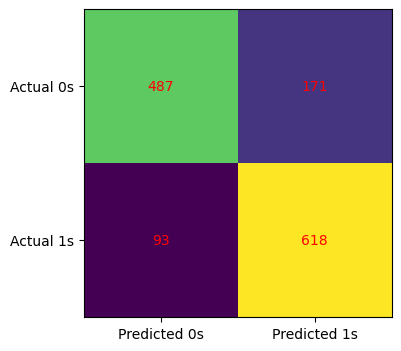

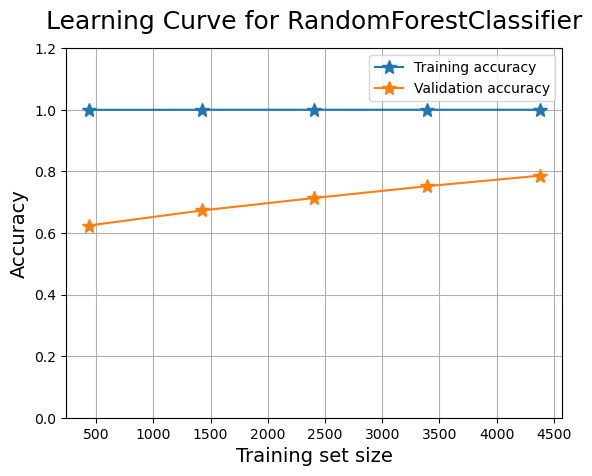

Best parameters for DecisionTreeClassifier:
{'classifier__splitter': 'best', 'classifier__min_samples_split': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': None, 'classifier': DecisionTreeClassifier(max_features='log2')}


Classification report for DecisionTreeClassifier:
              precision    recall  f1-score   support

           0       0.81      0.66      0.73       658
           1       0.73      0.86      0.79       711

    accuracy                           0.76      1369
   macro avg       0.77      0.76      0.76      1369
weighted avg       0.77      0.76      0.76      1369



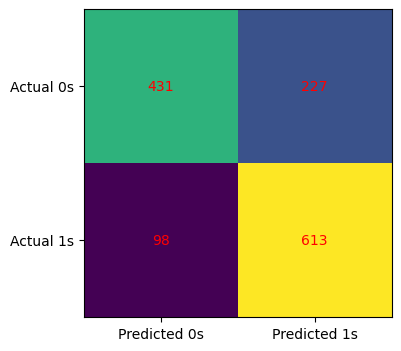

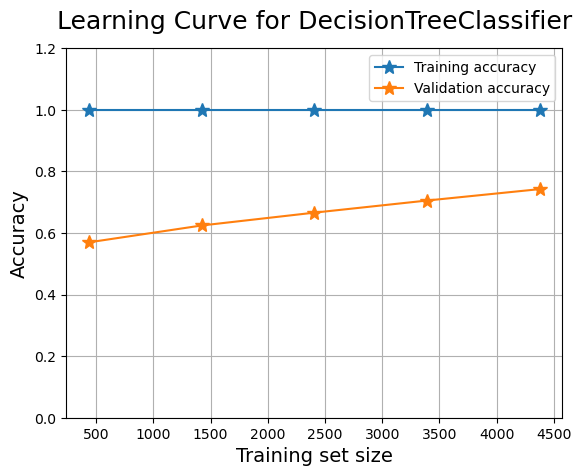

Best parameters for SVC:
{'classifier__kernel': 'rbf', 'classifier__C': 100, 'classifier': SVC(C=100)}


Classification report for SVC:
              precision    recall  f1-score   support

           0       0.72      0.67      0.69       658
           1       0.71      0.76      0.73       711

    accuracy                           0.71      1369
   macro avg       0.71      0.71      0.71      1369
weighted avg       0.71      0.71      0.71      1369



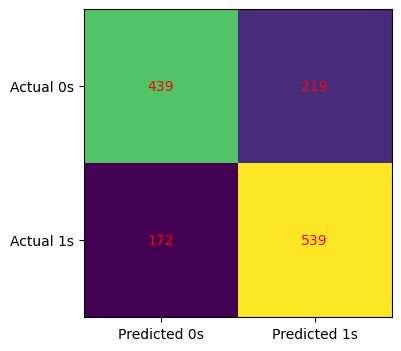

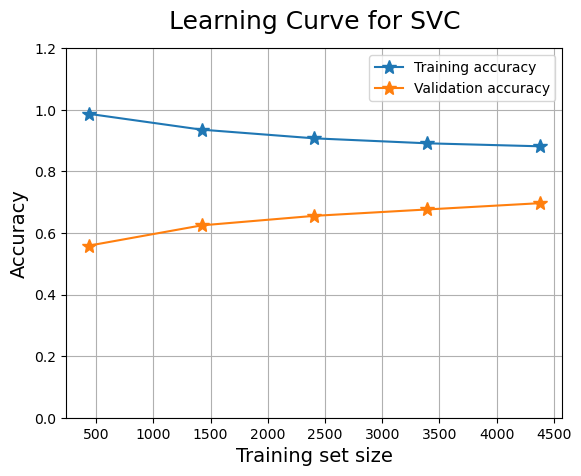

Best parameters for LogisticRegression:
{'classifier__solver': 'lbfgs', 'classifier__max_iter': 100, 'classifier__C': 10, 'classifier': LogisticRegression(C=10)}


Classification report for LogisticRegression:
              precision    recall  f1-score   support

           0       0.61      0.62      0.61       658
           1       0.64      0.64      0.64       711

    accuracy                           0.63      1369
   macro avg       0.63      0.63      0.63      1369
weighted avg       0.63      0.63      0.63      1369



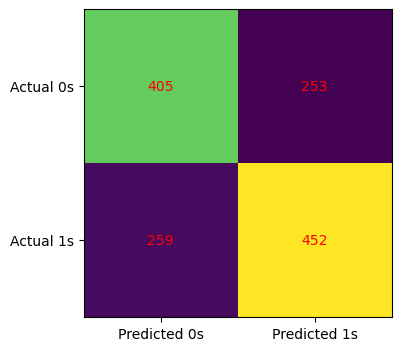

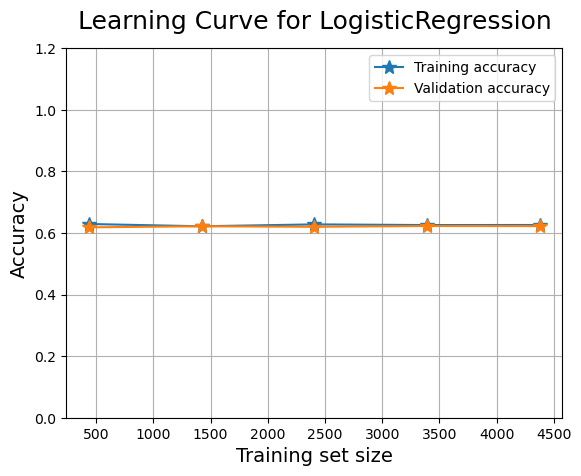

Best parameters for KNeighborsClassifier:
{'classifier__weights': 'distance', 'classifier__n_neighbors': 5, 'classifier': KNeighborsClassifier(weights='distance')}


Classification report for KNeighborsClassifier:
              precision    recall  f1-score   support

           0       0.84      0.58      0.69       658
           1       0.70      0.90      0.78       711

    accuracy                           0.74      1369
   macro avg       0.77      0.74      0.74      1369
weighted avg       0.76      0.74      0.74      1369



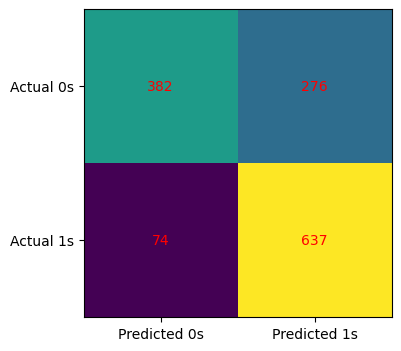

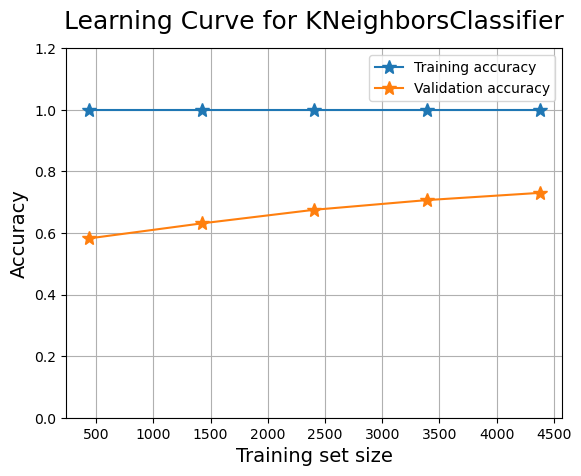

Best parameters for MLPClassifier:
{'classifier__solver': 'lbfgs', 'classifier__activation': 'tanh', 'classifier': MLPClassifier(activation='tanh', max_iter=1000, solver='lbfgs')}


Classification report for MLPClassifier:
              precision    recall  f1-score   support

           0       0.81      0.67      0.74       658
           1       0.74      0.86      0.79       711

    accuracy                           0.77      1369
   macro avg       0.78      0.77      0.77      1369
weighted avg       0.78      0.77      0.77      1369



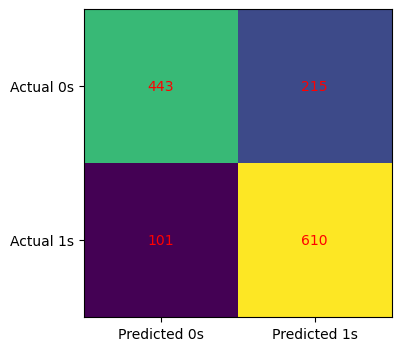

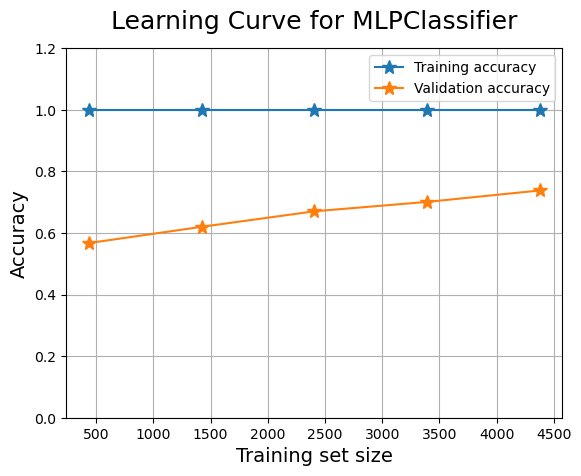

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.exceptions import ConvergenceWarning

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

import matplotlib.pyplot as plt
import warnings


def evalModel(model, X_train, X_test, y_train, y_test):
    """
        Function that evaluates the performance of a machine learning model on a test dataset; then, it
        plots the classification report and confusion matrix.

        :arg: model = machine learning model
              X_train, X_test, y_train, y_test = dataset splitting
    """

    # Suppress only convergence warnings during refit, after using higher max_iter where needed.
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print('\n')
    print(f"Classification report for {model.named_steps['classifier'].__class__.__name__}:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm)
    ax.grid(False)
    ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
    ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
    ax.set_ylim(1.5, -0.5)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='red')
    plt.show()
    print('\n')


# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), updated_num_col)
    ]
)

# Split the dataset into training and test sets
# stratify keeps the class proportion stable in train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)


# Definition of the models to be tested
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVC': SVC(),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'KNeighbors': KNeighborsClassifier(),
    'MLP': MLPClassifier(max_iter=3000, random_state=42)
}

# RepeatedStratifiedKFold: cross-validation strategy
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)


# Cross-validation for a set of models with fixed hyperparameters,
# providing an estimate of the average performance of each model.
for name, model in models.items():
    pipeline_1 = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        scores = cross_val_score(pipeline_1, X_train, y_train, cv=rskf, scoring='accuracy')

    print(f"{name} - Mean CV Accuracy: {np.mean(scores):.4f} +/- {np.std(scores):.4f}")
    # std: It measures the variability of the model's performance across different subsets of the data.
    # A low standard deviation indicates that the model is stable and consistent across different folds,
    # while a high standard deviation may indicate instability or overfitting.

print('\n')
print('------------------------------------------------------------')
print('\n')


# Parameters for GridSearchCV
# Since the grids are finite and relatively small, GridSearchCV is more appropriate than RandomizedSearchCV.
param_grid = [
    {
        'classifier': [RandomForestClassifier(random_state=42)],
        'classifier__n_estimators': [10, 50, 100],
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__criterion': ['gini', 'entropy', 'log_loss']
    },
    {
        'classifier': [DecisionTreeClassifier(random_state=42)],
        'classifier__max_depth': [None, 7, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__splitter': ['best', 'random'],
        'classifier__max_features': ['log2', 'sqrt', None]
    },
    {
        'classifier': [SVC()],
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'classifier': [LogisticRegression(max_iter=1000, random_state=42)],
        'classifier__C': [1, 0.1, 0.05, 10],
        'classifier__solver': ['lbfgs', 'liblinear', 'newton-cg'],
        'classifier__max_iter': [1000]
    },
    {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [3, 5, 11],
        'classifier__weights': ['uniform', 'distance']
    },
    {
        'classifier': [MLPClassifier(max_iter=3000, random_state=42)],
        'classifier__solver': ['adam', 'lbfgs'],
        'classifier__activation': ['relu', 'tanh'],
        'classifier__alpha': [0.0001, 0.001, 0.01]
    }
]


# Running GridSearchCV with cross-validation strategy for each classifier in param_grid
for param in param_grid:
    classifier = param['classifier'][0]
    pipeline_2 = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])

    search = GridSearchCV(
        estimator=pipeline_2,
        param_grid=param,
        cv=rskf,
        scoring='accuracy',
        n_jobs=-1
    )

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        search.fit(X_train, y_train)

    # Results
    print(f"Best parameters for {classifier.__class__.__name__}:\n{search.best_params_}")
    best_model = search.best_estimator_
    evalModel(best_model, X_train, X_test, y_train, y_test)

    # Learning curves using the tuned/best model
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        train_sizes, train_scores, validation_scores = learning_curve(
            estimator=best_model,
            X=X_train,
            y=y_train,
            cv=rskf,
            scoring='accuracy',
            shuffle=True,
            n_jobs=-1
        )

    train_scores_mean = train_scores.mean(axis=1)
    validation_scores_mean = validation_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_scores_mean, label='Training accuracy', marker='*', markersize=10)
    plt.plot(train_sizes, validation_scores_mean, label='Validation accuracy', marker='*', markersize=10)
    plt.ylabel('Accuracy', fontsize=14)
    plt.xlabel('Training set size', fontsize=14)
    plt.title(f'Learning Curve for {classifier.__class__.__name__}', fontsize=18, y=1.03)
    plt.legend()
    plt.grid()
    plt.ylim(0, 1.2)
    plt.show()

35/35 [==============================] - 1s 6ms/step


Mean CV Accuracy: 0.6572 +/- 0.0137
- - - - - - - -
class weights:  {0: 0.9904089757509953, 1: 1.009778597785978}


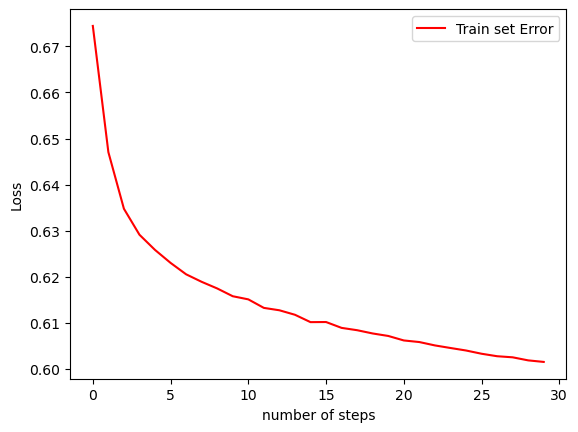

43/43 [==============================] - 0s 4ms/step
Classification report for MLP:
              precision    recall  f1-score   support

           0       0.66      0.58      0.62       658
           1       0.65      0.72      0.68       711

    accuracy                           0.65      1369
   macro avg       0.65      0.65      0.65      1369
weighted avg       0.65      0.65      0.65      1369



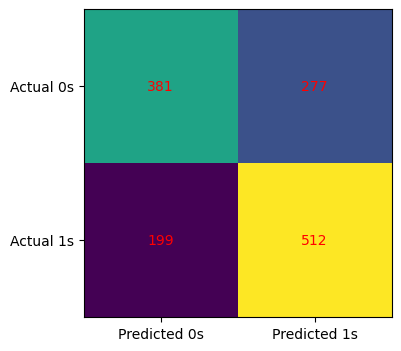

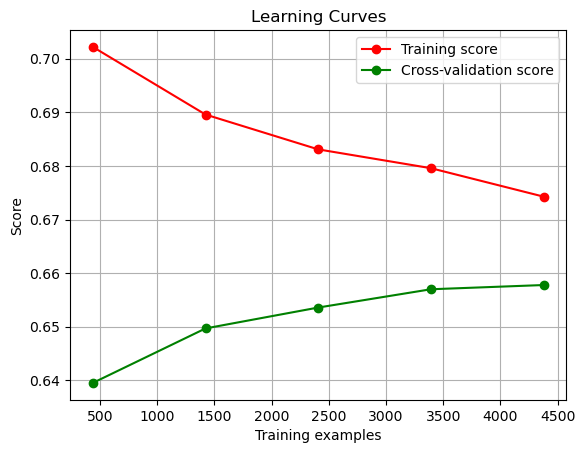

In [39]:
# MLP with TensorFlow
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import warnings

scaler = StandardScaler()

X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train_std[updated_num_col] = scaler.fit_transform(X_train[updated_num_col])
X_test_std[updated_num_col] = scaler.transform(X_test[updated_num_col])

# Function defined for subsequent use in KerasClassifier
def create_model(X):
    """
        This function defines and compiles a neural network model for binary classification.

        :arg: X = X_train
        :return: classifier = model
    """

    # Creating the Multi Layer Perceptron
    layers = [
        # First Hidden Layer
        tf.keras.layers.Dense(
            units=7,
            activation=tf.nn.relu,
            input_shape=(X.shape[1],)
        ),
        # Second Hidden Layer
        tf.keras.layers.Dense(units=5, activation=tf.nn.relu),
        # Output Layer
        tf.keras.layers.Dense(units=1, activation=tf.nn.sigmoid)
    ]

    # Creating a sequential model
    classifier = tf.keras.Sequential(layers)

    # Compile the model: optimizer, loss function and metrics
    precision = tf.keras.metrics.Precision()
    recall = tf.keras.metrics.Recall()
    classifier.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=['accuracy', precision, recall]
    )

    return classifier


# Create the Keras model.
# The TensorFlow sklearn wrapper is deprecated in some versions, so the warning is suppressed here
# to avoid local file paths in the notebook output.
with warnings.catch_warnings():
    warnings.simplefilter('ignore', DeprecationWarning)
    keras_model = tf.keras.wrappers.scikit_learn.KerasClassifier(
        build_fn=lambda: create_model(X_train_std),
        epochs=30,
        batch_size=32,
        verbose=0
    )


# Cross-validation scores
scores = cross_val_score(keras_model, X_train_std, y_train, cv=rskf, scoring='accuracy')
print('\n')
print(f"Mean CV Accuracy: {np.mean(scores):.4f} +/- {np.std(scores):.4f}")
print('- - - - - - - -')

# Calculation of Class Weights
class_weights = dict()
classes = np.unique(y_train)
total = len(y_train)
class_counts = np.bincount(y_train)

for c in classes:
    class_weight = total / (len(classes) * class_counts[c])
    class_weights[c] = class_weight
print('class weights: ', class_weights)

# Train the model on the full training set
history = keras_model.fit(X_train_std, y_train, class_weight=class_weights)

# Plot model structure
tf.keras.utils.plot_model(keras_model.model, show_shapes=True, show_layer_names=True)


# Plot progress in training
loss_history = history.history['loss']
plt.xlabel('Number of steps')
plt.ylabel('Loss')
plt.plot(loss_history, '-r', label='Train set error')
plt.legend(loc='upper right')
plt.show()


# Prediction on Test Set
y_predMLP = keras_model.predict(X_test_std)
print("Classification report for MLP:")
print(classification_report(y_test, y_predMLP, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_predMLP)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm)
ax.grid(False)
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.show()

# Learning Curves
train_sizes, train_scores, test_scores = learning_curve(
    keras_model,
    X_train_std,
    y_train,
    cv=rskf,
    scoring='accuracy',
    n_jobs=-1
)
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure()
plt.title('Learning Curves')
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.grid()
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
plt.legend(loc='best')
plt.show()